In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras



In [ ]:
Dataset = sklearn.datasets.load_breast_cancer()
Dataset

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
df = pd.DataFrame(Dataset.data,columns = Dataset.feature_names)


EDA/ Data Preproccesing


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df['Class'] = Dataset.target


In [ ]:
df.groupby('Class').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,0.609083,1.210915,4.323929,72.672406,0.006780,0.032281,0.041824,0.015060,0.020472,0.004062,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,0.284082,1.220380,2.000321,21.135148,0.007196,0.021438,0.025997,0.009858,0.020584,0.003636,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [ ]:
X = df.drop('Class', axis = 1)
y = df['Class']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)



In [ ]:
Scaler  = StandardScaler()
X_train_std  = Scaler.fit_transform(X_train)
X_test_std = Scaler.transform(X_test)

In [ ]:
print(X.shape,X_train.shape,X_test.shape)

(569, 30) (426, 30) (143, 30)


In [ ]:
tf.random.set_seed(3)

In [ ]:
model = keras.Sequential([keras.layers.Flatten(input_shape = (30,)),
                          keras.layers.Dense(15,activation='relu'),
                          keras.layers.Dense(10,activation='relu'),
                          keras.layers.Dense(2,activation='softmax')
                          ])


In [ ]:
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

In [ ]:
Training = model.fit(X_train_std,y_train,validation_split=0.1,epochs = 10)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6292 - loss: 0.6445 - val_accuracy: 0.7209 - val_loss: 0.5671
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7702 - loss: 0.5422 - val_accuracy: 0.8140 - val_loss: 0.4590
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8486 - loss: 0.4429 - val_accuracy: 0.9302 - val_loss: 0.3620
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9008 - loss: 0.3556 - val_accuracy: 0.9302 - val_loss: 0.2871
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9191 - loss: 0.2875 - val_accuracy: 0.9535 - val_loss: 0.2309
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9295 - loss: 0.2364 - val_accuracy: 0.9535 - val_loss: 0.1915
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9452 - loss: 0.1979 - val_accuracy: 0.9535 - val_loss: 0.1655
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9608 - loss: 0.1690 - val_accuracy: 0.9767 - val_lo

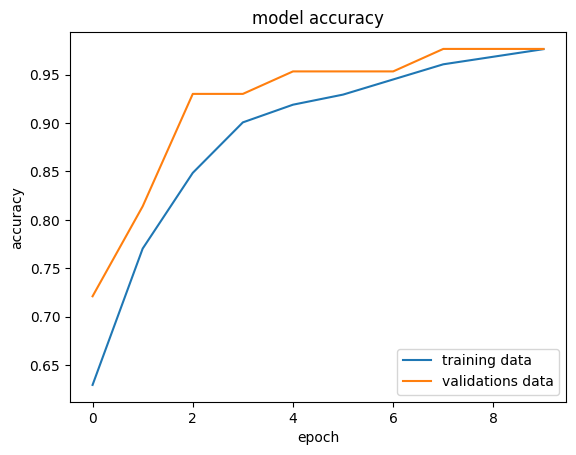

In [ ]:
#Visualizing Accuracy and the loss
plt.plot(Training.history['accuracy'])
plt.plot(Training.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(["training data",'validations data'], loc = 'lower right')

/tmp/ipykernel_1247/1863963882.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend("training data", "validation data", loc = "upper right")


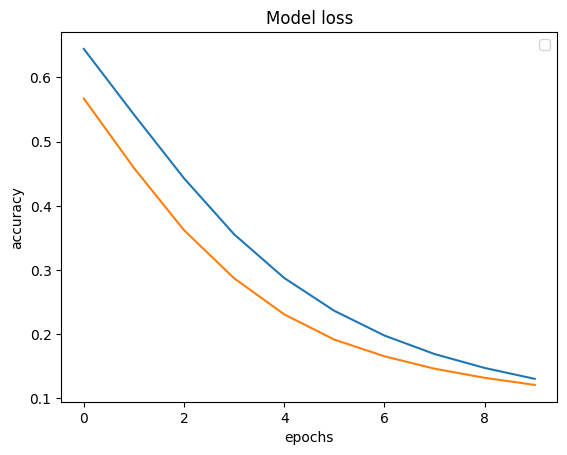

In [ ]:
plt.plot(Training.history['loss'])
plt.plot(Training.history['val_loss'])
plt.title('Model loss')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend("training data", "validation data", loc = "upper right")


In [ ]:
loss,accuracy = model.evaluate(X_test_std,y_test)
print('Test Accuracy = ',accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9580 - loss: 0.1202 
Test Accuracy =  0.9580419659614563


In [ ]:
y_pred = model.predict(X_test_std)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [ ]:
print(y_pred.shape)
y_pred[0]

(143, 2)


array([0.16321434, 0.8367856 ], dtype=float32)

In [ ]:
def Predictive_System(input_data):
  real_data_as_nparray = np.asarray(input_data)
  input_data_reshaped = real_data_as_nparray.reshape(1,-1)
  Scaled_input_data = Scaler.transform(input_data_reshaped)
  prediction = model.predict(Scaled_input_data)
  print(prediction)
  prediction_label = np.argmax(prediction,axis = 1)
  print(prediction_label)

  if (prediction_label[0] == 0):
    print("the Tumor is Malignant")
  else:
    print("The tumor is Benign")

In [ ]:
inputt = (20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.00522,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902)
Predictive_System(inputt)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
[[0.957272   0.04272797]]
[0]
the Tumor is Malignant
